# Comparaison d'algos en régression

Nous allons comparer les différentes méthodes de régression que nous avons vues jusqu'à présent, les moindres carrés avec toutes les variables, puis les moindres carrés avec les variables sélectionnées par le critère BIC avec un algo backward et par AIC.
Le nombre de bloc de la validation croisée vaut $k=10$ mais peut être modifié par l'utilisateur. Les données s'appellent *don* et la variable d'intérêt $Y$

In [18]:
import sys
!{sys.executable} -m pip install scikit-learn pandas numpy matplotlib patsy

Defaulting to user installation because normal site-packages is not writeable


In [ ]:
import pandas as pd; import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from patsy import dmatrix
import ols_step_sk
###
from sklearn.linear_model import Ridge, ElasticNet, Lasso
from sklearn.linear_model import RidgeCV, ElasticNetCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, train_test_split
###
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error
###
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
###
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [12]:
# Chargement initial pour exploration (variables originales, sans transformation)
# don = pd.read_csv("https://regression-avec-python.github.io/donnees/ozone.txt", header=0, sep=";", index_col=0)
# don.rename(columns={"O3": "Y"}, inplace=True)

# OU import direct suite à preparation.ipnyb
don = pd.read_csv("dfbase.csv", header=0, sep=",")

don.describe(include='all')

don.head()

,T12,T15,Ne12,N12,S12,E12,W12,Vx,O3v,nebulosite_SOLEIL,vent_NORD,vent_OUEST,vent_SUD,Y
0,13.4,15.0,7,0,0,3,0,9.35,95.6,0.0,0.0,0.0,0.0,63.6
1,15.0,15.7,4,3,0,0,0,5.40,100.2,1.0,1.0,0.0,0.0,89.6
2,7.9,10.1,8,0,0,7,0,19.30,105.6,0.0,0.0,0.0,0.0,79.0
3,13.1,11.7,7,7,0,0,0,12.60,95.2,0.0,1.0,0.0,0.0,81.2
4,14.1,16.0,6,0,0,0,6,-20.30,82.8,0.0,0.0,1.0,0.0,88.0


INUTILE SI PREPARATION DEJA EXECUTE - Codage des variables qualitatives

In [ ]:
# Données transformées : variables qualitatives déjà encodées en dummies puis calcul 
# Fichier ozone : vent (direction : N, S, E, O) → décomposé en composantes cartésiennes Vx et Vy par heure (6h, 9h, 12h, 15h, 18h)
# Vx=vitesse×cos(direction)  et  Vy=vitesse×sin(direction)

don = pd.read_csv("https://regression-avec-python.github.io/donnees/ozone_transf.txt", header=0, sep=";", index_col=0)
print(don.shape)
don.rename(columns={"maxO3": "Y"}, inplace=True)

don.head()
print(list(don.columns))
don.describe(include='all')

INUTILE SI PREPARATION DEJA EXECUTE - Définition du modèle et de l'espace des X (avec ou sans interactions)

In [13]:
nomsvar = list(don.columns.difference(["Y"]))
print("Variables explicatives :", nomsvar)

# Matrice de base
formule = "~" + "+".join(nomsvar)       # crée une formule de type R/Patsy, ex. : "~X1+X2+X3" qui signifie Y est expliqué par X1, X2 et X3"
print("Formule de base :", formule)
dsX = dmatrix(formule, don)
X = np.asarray(dsX)[:, 1:]  # conversion de la matrice en tableau Numpy et supprime la 1er colonne intercept qui avait été ajoutée automatiquement par patsy

# Interactions deux à deux
formuleI = "1 + (" + "+".join(nomsvar) + ")**2"
Xinter = dmatrix(formuleI, don, return_type="dataframe")
print("Variables avec interactions :", Xinter.design_info.column_names)
XI = np.asarray(Xinter)[:, 1:]

# Polynômes degrés 2 et 3
XP = np.concatenate((X, X**2, X**3), axis=1)

# Interactions + polynômes
XIP = np.concatenate((XI, XP), axis=1)

# ← Modifier ici pour tester différents espaces de features : X, XI, XP ou XIP
X = X   # si on veut modèle avec interactions uniquement : X = XI, etc
Y = don["Y"].to_numpy()     # extraction de la variable dépendante Y sous forme de tbleau Numpy

Variables explicatives : ['E12', 'N12', 'Ne12', 'O3v', 'S12', 'T12', 'T15', 'Vx', 'W12', 'nebulosite_SOLEIL', 'vent_NORD', 'vent_OUEST', 'vent_SUD']
Formule de base : ~E12+N12+Ne12+O3v+S12+T12+T15+Vx+W12+nebulosite_SOLEIL+vent_NORD+vent_OUEST+vent_SUD
Variables avec interactions : ['Intercept', 'E12', 'N12', 'Ne12', 'O3v', 'S12', 'T12', 'T15', 'Vx', 'W12', 'nebulosite_SOLEIL', 'vent_NORD', 'vent_OUEST', 'vent_SUD', 'E12:N12', 'E12:Ne12', 'E12:O3v', 'E12:S12', 'E12:T12', 'E12:T15', 'E12:Vx', 'E12:W12', 'E12:nebulosite_SOLEIL', 'E12:vent_NORD', 'E12:vent_OUEST', 'E12:vent_SUD', 'N12:Ne12', 'N12:O3v', 'N12:S12', 'N12:T12', 'N12:T15', 'N12:Vx', 'N12:W12', 'N12:nebulosite_SOLEIL', 'N12:vent_NORD', 'N12:vent_OUEST', 'N12:vent_SUD', 'Ne12:O3v', 'Ne12:S12', 'Ne12:T12', 'Ne12:T15', 'Ne12:Vx', 'Ne12:W12', 'Ne12:nebulosite_SOLEIL', 'Ne12:vent_NORD', 'Ne12:vent_OUEST', 'Ne12:vent_SUD', 'O3v:S12', 'O3v:T12', 'O3v:T15', 'O3v:Vx', 'O3v:W12', 'O3v:nebulosite_SOLEIL', 'O3v:vent_NORD', 'O3v:vent_OUEST',

Préparation Validation croisée

In [14]:
nb = 10  # nombre de blocs
# np.arange : génèration d'un séquence, chaque observation reçoit une étiquette entre 0 et 9, distribuée de façon cyclique (%nb est le modulo K)
tmp = np.arange(don.shape[0]) % nb
# mélange aléatoire des étiquettes
rng = np.random.default_rng(seed=1234)  # crée un générateur aléatoire reproductible (le seed garantit qu'on obtient toujours le même mélange)
bloc = rng.choice(tmp, size=don.shape[0], replace=False)  # affectation aléatoire aux blocs


# df PREV : création du tableau de résultats - stocke les prévisions de chaque modèle
PREV = pd.DataFrame({"bloc": bloc, "Y": don["Y"],
                     "MCO": 0.0, "BIC": 0.0, "AIC": 0.0,
                     "lasso": 0.0, "ridge": 0.0, "elastic": 0.0,
                     "ridgeGS": 0.0, "arbre": 0.0, "foret": 0.0,
                     "pcr": 0.0, "pls": 0.0})

Configuration des modèles

Sans pénalisation    →  MCO, BIC, AIC, PCR, PLS, Arbre, Forêt

Avec pénalisation    →  Lasso, Ridge, Elastic Net


Réduction de dim.    →  PCR (variance X), PLS (covariance X/Y)

In [15]:
# kf : KFold pour les méthodes pénalisées et arbres (10 blocs)
# kfaxes : KFold pour PCR et PLS (4 blocs, plus stable pour le choix du nb de composantes)

cr = StandardScaler()   # centre et réduit les variables (moyenne=0, écart-type=1) — indispensable pour les modèles pénalisés
kf = KFold(n_splits=10, shuffle=True, random_state=0)
kfaxes = KFold(n_splits=4, shuffle=True, random_state=0)
nbaxes = 20  # nb max de composantes à tester dans la grille (PCR et PLS)

lassocv = LassoCV(cv=kf)    # cherche automatiquement le meilleur lambda (force de pénalisation) par validation croisée
pipe_lassocv = Pipeline(steps=[("cr", cr), ("lassocv", lassocv)])   # applique d'abord la standardisation, puis le Lasso
etape_lassocv = pipe_lassocv.named_steps["lassocv"]    # on récupère le lamba optimal
lambdaoptlasso = []  # liste pour enregistrer le lambda optimal à chaque fold

enetcv = ElasticNetCV(cv=kf, max_iter=10000)
pipe_enetcv = Pipeline(steps=[("cr", cr), ("enetcv", enetcv)])

ridge = Ridge()
pipe_ridge = Pipeline(steps=[("cr", cr), ("ridge", ridge)])

# PCR : ACP + régression linéaire sur les composantes
acp = PCA()
reg_pcr = LinearRegression()
pipe_pcr = Pipeline(steps=[("cr", cr), ("acp", acp), ("reg", reg_pcr)])
param_grid_pcr = {"acp__n_components": list(range(1, nbaxes))}   # on teste sur 1 à 19 composantes → le meilleur nombre sera choisi par CV

# PLS : maximise la covariance entre X et Y dans l'espace réduit
regpls = PLSRegression()
param_grid_pls = {"n_components": list(range(1, nbaxes))}



In [16]:
'''# copier coller de arlette
###lasso
pipe_lassocv.fit(Xapp,Yapp)
print(lasso.coef_>0)
lambdaoptlasso.append(round(etape_lassocv.alpha_,4))
PREV.loc[PREV.bloc==i,"lasso"] = pipe_lassocv.predict(Xtest)
   
###elastic net pondération 1/2
pipe_enetcv.fit(Xapp,Yapp)
PREV.loc[PREV.bloc==i,"elastic"] = pipe_enetcv.predict(Xtest)
  
###ridge avec le chemin de reg qui vaut 100 le chemin de lasso
alphasridge = 100*etape_lassocv.alphas_
ridgecv = RidgeCV(cv=kf,alphas=alphasridge)
pipe_ridgecv = Pipeline(steps=[("cr", cr), ("ridgecv", ridgecv)])
pipe_ridgecv.fit(Xapp,Yapp)
PREV.loc[PREV.bloc==i,"ridge"] = pipe_ridgecv.predict(Xtest)
   
## ridge grid searchparams lambda
path_ridge = alphasridge  
param_grid_ridge = {"ridge__alpha": path_ridge}
cv_ridge = GridSearchCV(pipe_ridge, param_grid_ridge, cv=kf, scoring = "neg_mean_squared_error", n_jobs=3).fit(Xapp, Yapp)
PREV.loc[PREV.bloc==i,"ridgeGS"] = cv_ridge.predict(Xtest)
   
### arbre
arbre = DecisionTreeRegressor(min_sample_leaf=5).fit(Xapp,Yapp)
PREV.loc[PREV.bloc==i,"arbre"] = arbre.predict(Xtest)
   
### foret
foret = DecisionForestRegressor.fit(Xapp,Yapp)
PREV.loc[PREV.bloc==i,"foret"] = foret.predict(Xtest)'''

'# copier coller de arlette\n###lasso\npipe_lassocv.fit(Xapp,Yapp)\nprint(lasso.coef_>0)\nlambdaoptlasso.append(round(etape_lassocv.alpha_,4))\nPREV.loc[PREV.bloc==i,"lasso"] = pipe_lassocv.predict(Xtest)\n\n###elastic net pondération 1/2\npipe_enetcv.fit(Xapp,Yapp)\nPREV.loc[PREV.bloc==i,"elastic"] = pipe_enetcv.predict(Xtest)\n\n###ridge avec le chemin de reg qui vaut 100 le chemin de lasso\nalphasridge = 100*etape_lassocv.alphas_\nridgecv = RidgeCV(cv=kf,alphas=alphasridge)\npipe_ridgecv = Pipeline(steps=[("cr", cr), ("ridgecv", ridgecv)])\npipe_ridgecv.fit(Xapp,Yapp)\nPREV.loc[PREV.bloc==i,"ridge"] = pipe_ridgecv.predict(Xtest)\n\n## ridge grid searchparams lambda\npath_ridge = alphasridge  \nparam_grid_ridge = {"ridge__alpha": path_ridge}\ncv_ridge = GridSearchCV(pipe_ridge, param_grid_ridge, cv=kf, scoring = "neg_mean_squared_error", n_jobs=3).fit(Xapp, Yapp)\nPREV.loc[PREV.bloc==i,"ridgeGS"] = cv_ridge.predict(Xtest)\n\n### arbre\narbre = DecisionTreeRegressor(min_sample_leaf=5)

Exécution des modèles en validation croisée

In [ ]:
for i in np.arange(nb):
    print(i)
    Xapp  = X[bloc != i, :]         # lignes dont le bloc ≠ i  → apprentissage (90%)
    Xtest = X[bloc == i, :]         # lignes dont le bloc = i  → test (10%)
    Yapp  = don[bloc != i]["Y"]
    Ytest = don[bloc == i]["Y"]     #  Ytest est défini mais pas utilisé directement dans la boucle, car les prédictions sont stockées dans PREV et comparées à Y plus tard.

    ### MCO (toutes variables, sans sélection ni pénalité)
    reg = LinearRegression()
    reg.fit(Xapp, Yapp)
    PREV.loc[PREV.bloc == i, "MCO"] = reg.predict(Xtest)

    ### BIC (commenté : coûteux quand le nb de features est grand)
    # inst_reg_bic = ols_step_sk.LinearRegressionSelectionFeatureIC(verbose=1, crit="bic")
    # reg_bic = inst_reg_bic.fit(X=Xapp, y=Yapp)
    # PREV.loc[PREV.bloc==i, "BIC"] = reg_bic.predict(Xtest)

    ### AIC
    # inst_reg_aic = ols_step_sk.LinearRegressionSelectionFeatureIC(verbose=1, crit="aic")
    # reg_aic = inst_reg_aic.fit(X=Xapp, y=Yapp)
    # PREV.loc[PREV.bloc==i, "AIC"] = reg_aic.predict(Xtest)

    ### Lasso (sélection de variables via pénalité L1)
    pipe_lassocv.fit(Xapp, Yapp)
    lambdaoptlasso.append(round(etape_lassocv.alpha_, 4))  # lambda optimal de ce fold
    PREV.loc[PREV.bloc == i, "lasso"] = pipe_lassocv.predict(Xtest)

    ### ElasticNet (compromis L1/L2)
    pipe_enetcv.fit(Xapp, Yapp)
    PREV.loc[PREV.bloc == i, "elastic"] = pipe_enetcv.predict(Xtest)

    ### Ridge via RidgeCV (grille calée sur le chemin lasso × 100)
    # etape_lassocv.alphas_ : grille de lambdas déjà explorée par le Lasso
    # × 100 : le Ridge nécessite des lambdas beaucoup plus grands que le Lasso (échelles différentes)
    # RidgeCV : méthode rapide intégrée à scikit-learn
    alphasridge = 100 * etape_lassocv.alphas_
    ridgecv = RidgeCV(cv=kf, alphas=alphasridge)
    pipe_ridgecv = Pipeline(steps=[("cr", cr), ("ridgecv", ridgecv)])
    pipe_ridgecv.fit(Xapp, Yapp)
    PREV.loc[PREV.bloc == i, "ridge"] = pipe_ridgecv.predict(Xtest)

    ### Ridge via GridSearchCV (alternative plus flexible)
    # Même grille de lambdas, mais via GridSearchCV — plus flexible (on peut changer le scoring, paralléliser)
    # n_jobs=3 : parallélisation sur 3 cœurs
    # neg_mean_squared_error : on minimise le MSE (négatif car GridSearchCV maximise par convention)
    param_grid_ridge = {"ridge__alpha": alphasridge}
    cv_ridge = GridSearchCV(pipe_ridge, param_grid_ridge, cv=kf,
                            scoring="neg_mean_squared_error", n_jobs=3).fit(Xapp, Yapp)
    PREV.loc[PREV.bloc == i, "ridgeGS"] = cv_ridge.predict(Xtest)

    ### Arbre de décision (min 5 obs par feuille pour limiter le surapprentissage)
    arbre = DecisionTreeRegressor(min_samples_leaf=5).fit(Xapp, Yapp)
    PREV.loc[PREV.bloc == i, "arbre"] = arbre.predict(Xtest)

    ### Forêt aléatoire
    foret = RandomForestRegressor().fit(Xapp, Yapp)
    PREV.loc[PREV.bloc == i, "foret"] = foret.predict(Xtest)

    ### PCR : ACP puis régression linéaire sur les composantes
    ### nb de composantes choisi par GridSearchCV avec kfaxes (4 blocs)
    cv_pcr = GridSearchCV(pipe_pcr, param_grid_pcr, cv=kfaxes,
                          scoring="neg_mean_squared_error", n_jobs=3).fit(Xapp, Yapp)
    PREV.loc[PREV.bloc == i, "pcr"] = cv_pcr.predict(Xtest)

    ### PLS : maximise la covariance entre X et Y dans l'espace réduit
    ### avantage sur PCR : tient compte de Y pour construire les composantes
    cv_pls = GridSearchCV(regpls, param_grid_pls, cv=kfaxes,
                          scoring="neg_mean_squared_error", n_jobs=3).fit(Xapp, Yapp)
    PREV.loc[PREV.bloc == i, "pls"] = cv_pls.predict(Xtest)

    ### gradient boosting
    ######## A COMPLETER AVEC FICHIER DU PROF ####################
    params = dict(n_estimators=1000, max_depth=5, learning_rate=0.1, random_state=42)
    gbm_early_stopping = GradientBoostingRegressor(**params,validation_fraction=0.1,n_iter_no_change=10)
    gbm_early_stopping.fit(Xapp,Yapp)
    print(gbm_early_stopping.n_estimators_)
    PREV.loc[PREV.bloc==i, "gbm1"] = gbm_early_stopping.predict(Xtest)
   
    params = dict(n_estimators=1000, max_depth=2, learning_rate=0.1, random_state=42)
    gbm_early_stopping = GradientBoostingRegressor(**params,validation_fraction=0.1,n_iter_no_change=10)
    gbm_early_stopping.fit(Xapp,Yapp)
    print(gbm_early_stopping.n_estimators_)
    PREV.loc[PREV.bloc==i, "gbm2"] = gbm_early_stopping.predict(Xtest)


0


/opt/python/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
24 fits failed out of a total of 76.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
4 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/python/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/python/lib/python3.13/site-packages/sklearn/base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/opt/python/lib/python3.13/site-packages/sklearn/pipeline.py", line 613, in fit
    Xt = self._fit(X, y, routed_params

38
37
1


/opt/python/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
24 fits failed out of a total of 76.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
4 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/python/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/python/lib/python3.13/site-packages/sklearn/base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/opt/python/lib/python3.13/site-packages/sklearn/pipeline.py", line 613, in fit
    Xt = self._fit(X, y, routed_params

154
36
2


...

/opt/python/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
24 fits failed out of a total of 76.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
4 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/python/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/python/lib/python3.13/site-packages/sklearn/base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/opt/python/lib/python3.13/site-packages/sklearn/pipeline.py", line 613, in fit
    Xt = self._fit(X, y, routed_params

111
28
8


/opt/python/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
24 fits failed out of a total of 76.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
4 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/python/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/python/lib/python3.13/site-packages/sklearn/base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/opt/python/lib/python3.13/site-packages/sklearn/pipeline.py", line 613, in fit
    Xt = self._fit(X, y, routed_params

16
28
9
50
31


/opt/python/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
24 fits failed out of a total of 76.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
4 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/python/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/python/lib/python3.13/site-packages/sklearn/base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/opt/python/lib/python3.13/site-packages/sklearn/pipeline.py", line 613, in fit
    Xt = self._fit(X, y, routed_params

Comparaison des performances des modèles via MSE (plus petit = meilleur)

In [22]:
# MSE de chaque méthode
prev = PREV.iloc[:, 1:]     # iloc[:, 1:] sélectionne toutes les lignes, et toutes les colonnes à partir de la 2ème. On exclut la colonne bloc (colonne 0), qui n'est pas une prédiction
# moyenne des différences entre Y et Y prev au carré
np.round((prev.sub(PREV.Y, axis=0)**2).mean(), 2)   # prev.sub(PREV.Y, axis=0) : soustrait Y de chaque colonne de prev

Y             0.00
MCO         226.85
BIC        8007.51
AIC        8007.51
lasso       214.41
ridge       267.91
elastic     213.98
ridgeGS     213.34
arbre       256.95
foret       196.95
pcr         237.94
pls         232.17
gbm1        258.83
gbm2        205.71
dtype: float64

Enregistrer le fichier résultats pour exploitation dans code AnalyseReg

In [39]:
PREV.to_csv("PREV.csv", index=False)

Evaluation du lambda optimal du lasso

In [34]:
# Lambda optimal du Lasso par fold : montre la variabilité du paramètre de régularisation
print(lambdaoptlasso)

[np.float64(0.2361), np.float64(0.0966), np.float64(0.2698), np.float64(0.1009), np.float64(0.104), np.float64(0.1266), np.float64(0.1103), np.float64(0.1019), np.float64(0.1379), np.float64(0.088)]



📊 Analyse de stabilité du Lambda Lasso
   Moyenne     : 0.1372
   Écart-type  : 0.0599
   CV (%)      : 43.7%
   ⚠  Lambda très variable : le modèle Lasso est instable sur ces données.


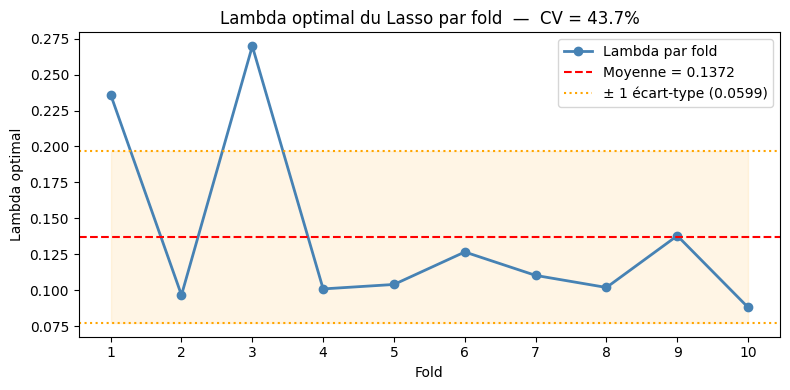

In [40]:
# visualiation de la variabilité du lambda optimal

# ── 1. Utilisation directe de la liste en mémoire ─────────────────────────────
vals = np.array(lambdaoptlasso)
moy  = vals.mean()
std  = vals.std()
cv   = 100 * std / moy

# ── 2. Métriques ───────────────────────────────────────────────────────────────
print(f"\n📊 Analyse de stabilité du Lambda Lasso")
print(f"   Moyenne     : {moy:.4f}")
print(f"   Écart-type  : {std:.4f}")
print(f"   CV (%)      : {cv:.1f}%")

if cv > 30:
    print("   ⚠  Lambda très variable : le modèle Lasso est instable sur ces données.")
else:
    print("   ✅ Lambda stable : bonne reproductibilité du modèle Lasso.")

# ── 3. Visualisation ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(range(1, len(vals)+1), vals,
        marker="o", color="steelblue", linewidth=2, label="Lambda par fold")

ax.axhline(y=moy, color="red", linestyle="--",
           label=f"Moyenne = {moy:.4f}")

ax.axhline(y=moy + std, color="orange", linestyle=":",
           label=f"± 1 écart-type ({std:.4f})")
ax.axhline(y=moy - std, color="orange", linestyle=":")

ax.fill_between(range(1, len(vals)+1),
                moy - std, moy + std,
                alpha=0.1, color="orange")

ax.set_title(f"Lambda optimal du Lasso par fold  —  CV = {cv:.1f}%")
ax.set_xlabel("Fold")
ax.set_ylabel("Lambda optimal")
ax.set_xticks(range(1, len(vals)+1))
ax.legend()
plt.tight_layout()
plt.show()
